In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, segmentation, measure

### Compare cell mask size distributions between raw and affine-transformed w/ expansion bright-field time series (0720206)
1. Plot both cell area and difference in cell area (between the two workflows) distributions 

In [ ]:
#no preprocessing (e.g., removing dead or excluded cells) on either dataset bc didn't run affine-transformed img through Cell-ACDC
rawmaskdata=pd.read_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_acdc_output_cpsam-d25.csv')
affmask=io.imread(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_segm_06102026_afftransf_cpsam-d25.tif')
int_affmask=affmask.astype(np.int64)
expsnmask=io.imread(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_cpsam-d25_afftransf-expand.tif')
int_expsnmask=expsnmask.astype(np.int64)

scale_factor=2*(1/1.05)

In [5]:
int_affmask.shape

(61, 1024, 1022)

In [31]:
def measure_cells(img_cell: np.ndarray):
    """
    Args:
    Outputs:
    """
    dfs=[]
    for time in range(img_cell.shape[0]):
        # for cell in measure.regionprops(img_cell[time,:,:]): #for each cell in the cell mask image...
        measured = measure.regionprops_table(img_cell[time,:,:], properties=('label','area','centroid', 'bbox'))
        df = pd.DataFrame(measured)
        df['frame_i']=[time for i in range(len(df.index))]
        df.rename(columns={'label':'Cell_ID'},inplace=True) #rename 'label' column 
        dfs.append(df)
        print("completed frame "+str(time))
    output_df=pd.concat(dfs, ignore_index=True)
    return output_df
    # return

In [35]:
affdf=measure_cells(int_affmask)
expsndf=measure_cells(int_expsnmask)

completed frame 0
completed frame 1
completed frame 2
completed frame 3
completed frame 4
completed frame 5
completed frame 6
completed frame 7
completed frame 8
completed frame 9
completed frame 10
completed frame 11
completed frame 12
completed frame 13
completed frame 14
completed frame 15
completed frame 16
completed frame 17
completed frame 18
completed frame 19
completed frame 20
completed frame 21
completed frame 22
completed frame 23
completed frame 24
completed frame 25
completed frame 26
completed frame 27
completed frame 28
completed frame 29
completed frame 30
completed frame 31
completed frame 32
completed frame 33
completed frame 34
completed frame 35
completed frame 36
completed frame 37
completed frame 38
completed frame 39
completed frame 40
completed frame 41
completed frame 42
completed frame 43
completed frame 44
completed frame 45
completed frame 46
completed frame 47
completed frame 48
completed frame 49
completed frame 50
completed frame 51
completed frame 52
com

In [36]:
affdf.to_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_cpsam-d25_afftransf.csv',index=False) #save dataframe as csv file.
# expsndf.to_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_cpsam-d25_afftransf-expand.csv',index=False) 

In [39]:
area_diffs=[]
area_ratios=[]
for cell_id in np.unique(rawmaskdata['Cell_ID'].values):
    cellrows_raw=rawmaskdata.loc[rawmaskdata.Cell_ID==cell_id]
    cellrows_aff=affdf.loc[affdf.Cell_ID==cell_id]
    for frame in range(max(rawmaskdata['frame_i'])):
        area_diffs.append(rawmaskdata.loc[rawmaskdata.frame_i==frame, 'cell_area_pxl'].values[0]-(scale_factor**2)*affdf.loc[affdf.frame_i==frame, 'area'].values[0])
        area_ratios.append(rawmaskdata.loc[rawmaskdata.frame_i==frame, 'cell_area_pxl'].values[0]/((scale_factor**2)*affdf.loc[affdf.frame_i==frame, 'area'].values[0]))

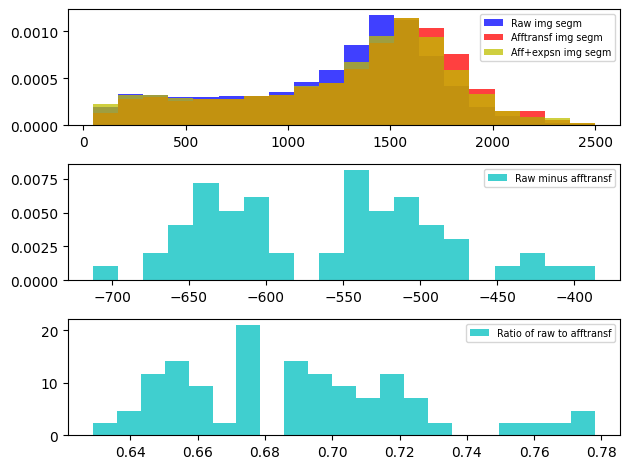

In [44]:
colors=['b','r','c','y','k']
fig,axes=plt.subplots(nrows=3,ncols=1)
# for i in range(vo_frames.shape[0]):

n0,b0,p0=axes[0].hist(rawmaskdata['cell_area_pxl'].values,bins='doane', alpha=0.75,density=True,label='Raw img segm', color=colors[0])
axes[0].hist((scale_factor**2)*affdf['area'].values,bins=b0, alpha=0.75,density=True,label='Afftransf img segm', color=colors[1])
axes[0].hist((scale_factor**2)*expsndf['area'].values,bins=b0, alpha=0.75,density=True,label='Aff+expsn img segm', color=colors[3])
axes[1].hist(area_diffs,bins='doane', alpha=0.75,density=True,label='Raw minus afftransf', color=colors[2])
axes[2].hist(area_ratios,bins='doane', alpha=0.75,density=True,label='Ratio of raw to afftransf', color=colors[2])
axes[0].legend(fontsize='x-small')
axes[1].legend(fontsize='x-small')
axes[2].legend(fontsize='x-small')
# axes[0].set_xlim(0,75)
# axes[1].set_xlim(0,25)    
# axes[2].set_xlim(0,75)
# fig.supxlabel('Cell Area (px)')
# fig.suptitle('Frame Pixel Distributions over Time (45 min intervals)')
fig.tight_layout()

### Turn affine transformation interpolation border into cell mask values via expansion (07172026)

In [ ]:
# def remove_interp_pixels(img: np.ndarray):
#     """
#     Args: 3D Cell mask image (t,y,x) with non-integer, interpolated pixels.
#     Outputs: Cell mask image with said pixel values set to zero.
#     """
#     (time,yaxis,xaxis)=img.shape
#     for t in range(time):
#         for y in range(yaxis):
#             for x in range(xaxis):
#                 if img[t,y,x]%1!=0:
#                     img[t,y,x]=0
#     return img 

In [4]:
img_affpath=r'C:\Users\jglic\Downloads\07152026 3c-ey2795\cell_segment\BF-timelapse_07152026_3c-ey2795_glucose-2.0_fov1_segm-afftransf.tif'
img_aff=io.imread(img_affpath)

# img_nobord=remove_interp_pixels(img_aff)
# io.imsave(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\BF-timelapse_cpsam-d25_afftransf-nobord.tif',img_nobord)

img_expand=segmentation.expand_labels(img_aff, distance=1) #turns out that this effectively removes the non-integer border pixels, and much faster as well. 
io.imsave(r'C:\Users\jglic\Downloads\07152026 3c-ey2795\cell_segment\BF-timelapse_cpsam-d25_afftransf-expand-1.tif',img_expand)


### 07102026
1. Evaluating presence of photobleaching in first 3 hr run with five confocal captures.

In [5]:
ynb_path=r'C:\Users\jglic\Downloads\07102026 3c-ey2796\confynb-jg_07102026_ey2795_glucose-2.0_fov1.tif'
red_path=r'C:\Users\jglic\Downloads\07102026 3c-ey2796\confred-jg_07102026_ey2795_glucose-2.0_fov1.tif'
ynb_stack=io.imread(ynb_path) #shape of (5,40,1024,1024,2) corr to (t,z,y,x,c)
ld_img=io.imread(red_path)
vo_img,gl_img=ynb_stack[:,:,:,0],ynb_stack[:,:,:,1]

In [11]:
vo_frames=[]
gl_frames=[]
ld_frames=[]
for i in range(vo_img.shape[0]): #flatten each time frame
    vo_frames.append(vo_img[i,:,:,:].flatten())
    gl_frames.append(gl_img[i,:,:,:].flatten())
    ld_frames.append(ld_img[i,:,:,:].flatten())
vo_frames=np.array(vo_frames)
gl_frames=np.array(gl_frames)
ld_frames=np.array(ld_frames)

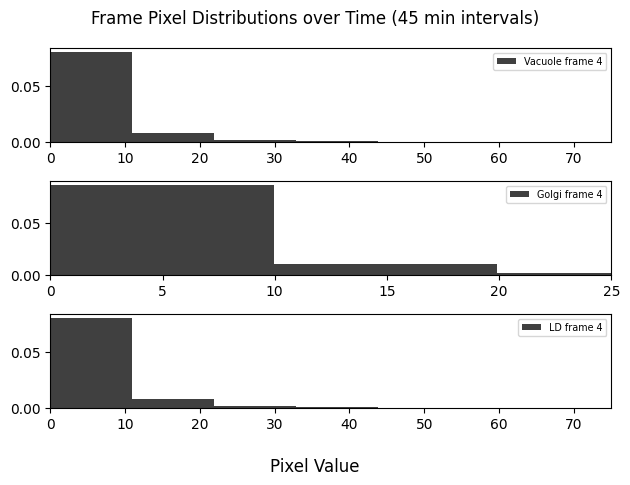

In [20]:
colors=['b','r','c','y','k']
fig,axes=plt.subplots(nrows=3,ncols=1)
# for i in range(vo_frames.shape[0]):
i=4
axes[0].hist(vo_frames[i,:],bins='doane', alpha=0.75,density=True,label='Vacuole frame '+str(i), color=colors[i])
axes[1].hist(gl_frames[i,:],bins='doane', alpha=0.75,density=True,label='Golgi frame '+str(i), color=colors[i])
axes[2].hist(vo_frames[i,:],bins='doane', alpha=0.75,density=True,label='LD frame '+str(i), color=colors[i])
axes[0].legend(fontsize='x-small')
axes[1].legend(fontsize='x-small')
axes[2].legend(fontsize='x-small')
axes[0].set_xlim(0,75)
axes[1].set_xlim(0,25)    
axes[2].set_xlim(0,75)
fig.supxlabel('Pixel Value')
fig.suptitle('Frame Pixel Distributions over Time (45 min intervals)')
fig.tight_layout()

In [2]:
csv_path=r'C:\Users\jglic\Downloads\12-16-2025 erg6-sec61 haploid\20251216_BF-timelapse_acdc_output_cpsam-d20_afftransf+HE.csv' 
df=pd.read_csv(csv_path)

In [3]:
df

,frame_i,Cell_ID,time_minutes,time_hours,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,...,moments_central-3-0,moments_central-3-1,moments_central-3-2,moments_central-3-3,bbox-0,bbox-1,bbox-2,bbox-3,velocity_pixel,velocity_um
0,0,1,0.0,0.000000,S,2.0,2.0,mother,-1.0,-1.0,...,-3177.077212,-51466.887559,96530.084818,-2.444086e+06,35,366,59,390,NaN,NaN
1,0,2,0.0,0.000000,S,0.0,1.0,bud,-1.0,-1.0,...,-3548.278236,32107.116838,131334.083260,1.495280e+06,44,350,63,369,NaN,NaN
2,0,3,0.0,0.000000,S,2.0,5.0,mother,-1.0,-1.0,...,1154.941432,-38660.474734,-169521.612087,-1.659762e+06,58,367,84,394,NaN,NaN
3,0,4,0.0,0.000000,S,2.0,9.0,mother,-1.0,-1.0,...,387.226685,-111878.936134,43328.014063,-5.100833e+06,61,395,85,414,NaN,NaN
4,0,5,0.0,0.000000,S,0.0,3.0,bud,-1.0,-1.0,...,970.937519,10586.147439,-69319.522173,4.217455e+05,62,348,82,368,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,23,112,115.0,1.916667,S,1.0,118.0,mother,20.0,20.0,...,3785.175133,-50376.120460,-86265.678801,-2.310588e+06,315,368,340,391,1.884416,0.408918
1297,23,114,115.0,1.916667,S,0.0,30.0,bud,21.0,-1.0,...,-1002.387312,24066.586231,27754.532238,6.932984e+05,304,246,322,265,3.054676,0.662865
1298,23,116,115.0,1.916667,S,0.0,4.0,bud,22.0,-1.0,...,258.277048,-168.835374,-1942.334800,-5.559206e+03,54,412,65,423,0.829521,0.180006
1299,23,118,115.0,1.916667,S,0.0,112.0,bud,22.0,-1.0,...,70.484933,3066.629740,5765.341559,9.457180e+04,322,351,338,368,0.461616,0.100171


In [ ]:
#Define function to take in dataframe and optional graph Title arg, and return # cells vs time graph.
def plot_numcells(df, Title=False):
    """Args:
       Outputs: 
    """
    plt.figure()
    # counts=0 #take only unique values from num_objects column. only poses a problem when non monotonic. 
    plt.plot(np.arange(0,len(counts),step=1), counts) #plot area as function of time
    plt.scatter(np.arange(0,len(counts),step=1),counts,label='all cells')
    plt.xlabel('Time (min)')
    plt.ylabel('# Cells')
    if Title==True:
        plt.title(input())
    # plt.legend()

#Define function to take in dataframe, start/stop bounds for Cell_IDs to consider, and optional graph Title arg, and return A(t) for each cell on same graph.
def plot_avt(df, rstart, rstop, Title=False):
    plt.figure() 
    for ID in np.arange(rstart,rstop,step=1): #for each Cell_ID in data...
        mask=df['Cell_ID'].values==ID #create a mask to extract that Cell_ID's rows
        ID_subset=df[mask] #apply mask
        plt.plot(ID_subset['time_minutes'].values,ID_subset['cell_area_pxl'].values) #plot area as function of time
        plt.scatter(ID_subset['time_minutes'].values,ID_subset['cell_area_pxl'].values, label='Cell_'+str(ID))
    plt.xlabel('Time (min)')
    plt.ylabel('Cell Area (px)')
    if Title==True:
        plt.title(input())
    # plt.legend()

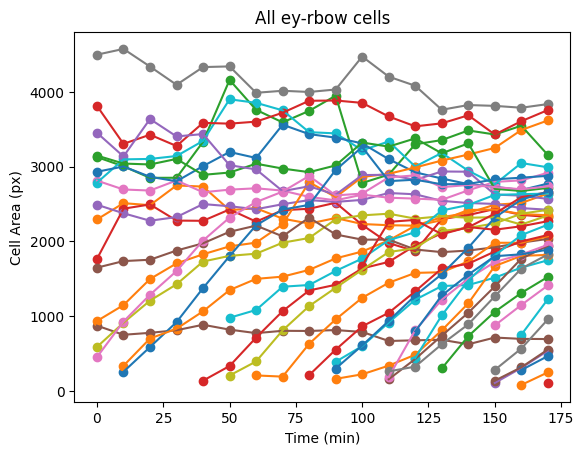

In [27]:
plot_avt(data,0,max(data.Cell_ID),Title=True)

In [37]:
# plot_avt(data,16,54,Title=True)